In [1]:
library(Giotto)
library(data.table)
library(data.table)
library(Matrix)


In [16]:
library(Giotto)

# 1. Directly from the file paths
path_to_matrix = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/deconvolution/Cytospace/st_expression.tsv"
path_to_locations =  "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/deconvolution/Cytospace/spatial_coords.tsv"
my_python_path <- "/home/qyyuan/anaconda3/envs/SpatialDWLS/bin/python"
my_instructions <- createGiottoInstructions(
    python_path = my_python_path
)
my_giotto_object = createGiottoObject(raw_exprs = path_to_matrix,
                  spatial_locs = path_to_locations,instructions = my_instructions)





 external python path provided and will be used 
Consider to install these (optional) packages to run all possible Giotto commands for spatial analyses:  scran MAST smfishHmrf trendsceek SPARK multinet RTriangle FactoMiner
 Giotto does not automatically install all these packages as they are not absolutely required and this reduces the number of dependencies

Warning message in evaluate_spatial_locations(spatial_locs = spatial_locs, cores = cores, :
“There are non numeric or integer columns for the spatial location input at column position(s): 1
 The first non-numeric column will be considered as a cell ID to test for consistency with the expression matrix
 Other non numeric columns will be removed”


In [17]:
my_giotto_object <- filterGiotto(gobject = my_giotto_object,
             expression_threshold = 1,
             gene_det_in_min_cells = 10,
             min_det_genes_per_cell = 5)

In [18]:
my_giotto_object <- normalizeGiotto(gobject = my_giotto_object, scalefactor = 6000, verbose = T)



 first scale genes and then cells 


return_plot = TRUE and return_gobject = TRUE 

          plot will not be returned to object, but can still be saved with save_plot = TRUE or manually 


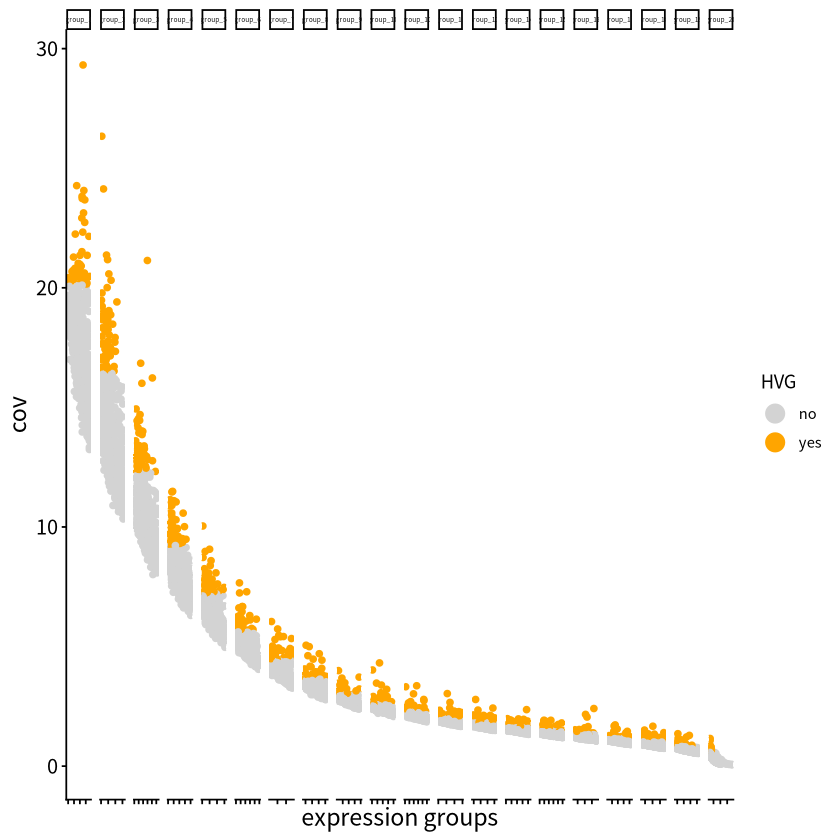

In [19]:
my_giotto_object <- calculateHVG(gobject = my_giotto_object)

hvg  was found in the gene metadata information and will be used to select highly variable genes 
PCA with name:  pca  already exists and will be used for the screeplot 


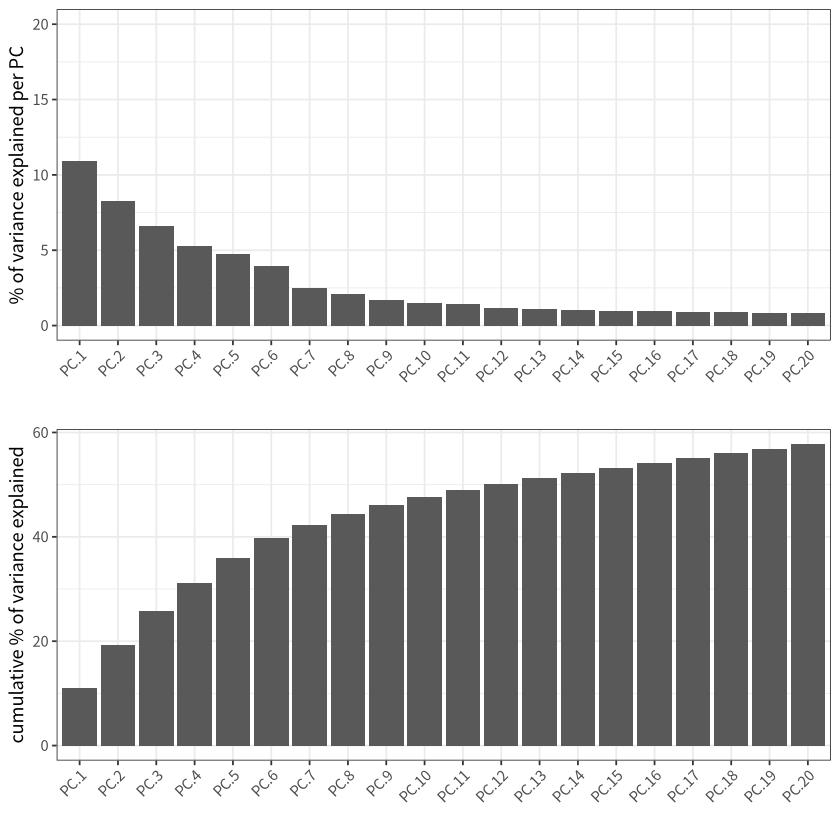

using 'jackstraw' to identify significant PCs If used in published research, please cite:
  Neo Christopher Chung and John D. Storey (2014).
  'Statistical significance of variables driving systematic variation in high-dimensional data. Bioinformatics

Estimating a number of significant principal component: 



1  2  3  4  5  6  7  8  9  10  number of estimated significant components:  181 


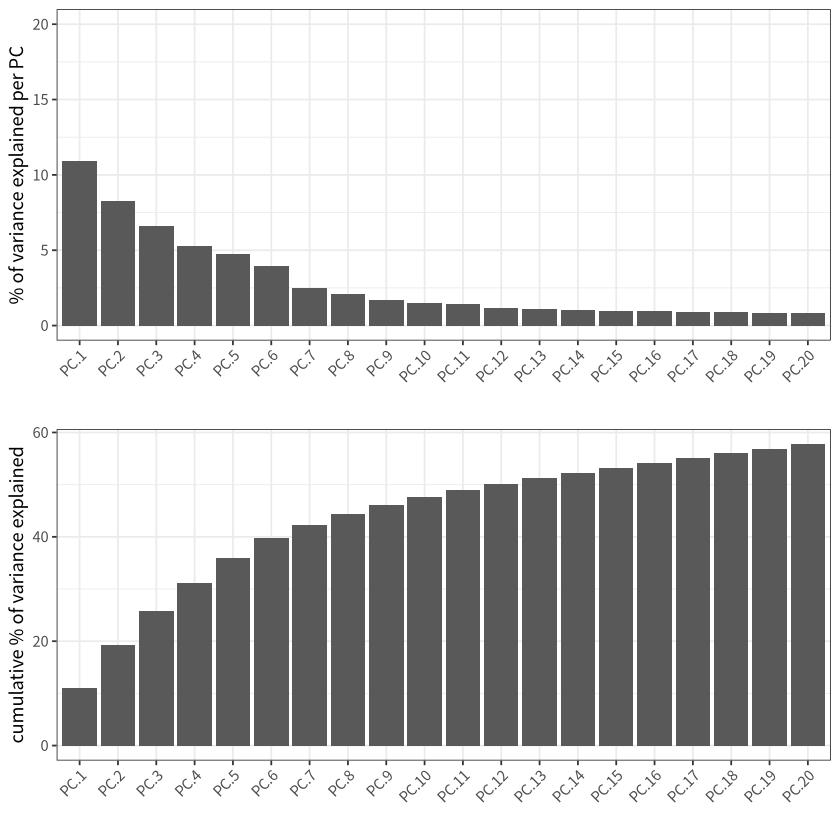

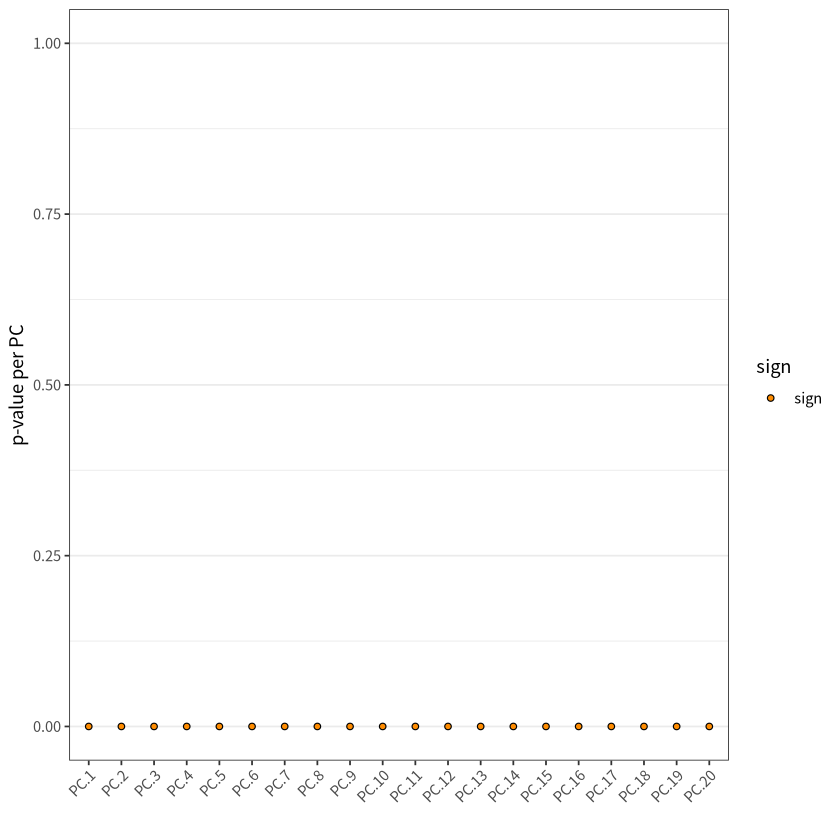

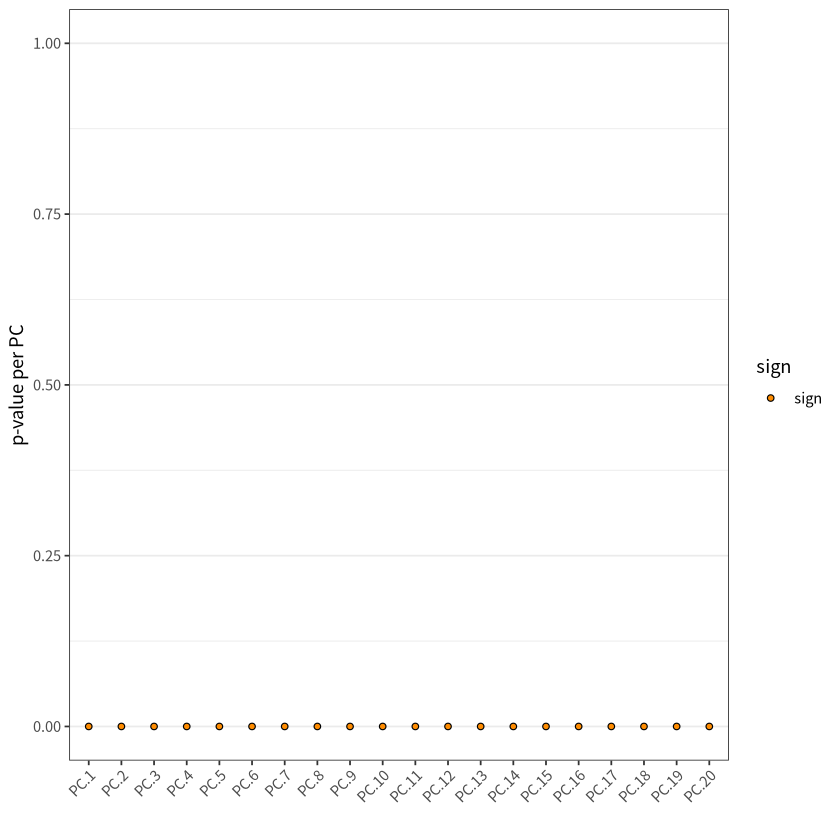

In [20]:
# Run PCA
my_giotto_object <- runPCA(gobject = my_giotto_object)

# Identify most informative principal components
screePlot(my_giotto_object, ncp = 20)
jackstrawPlot(my_giotto_object, ncp = 20)

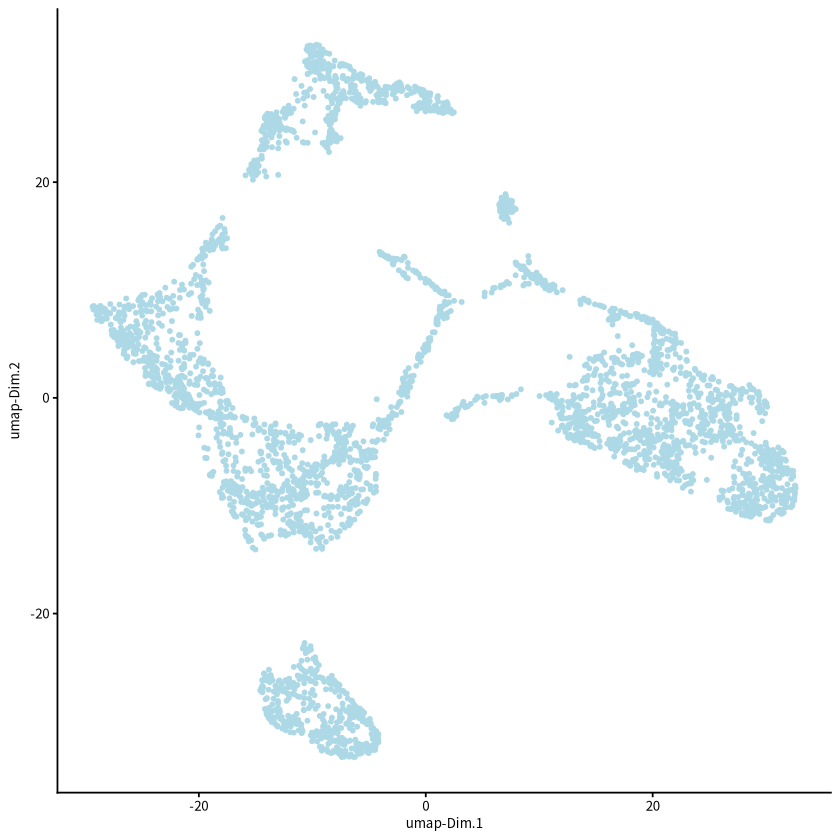

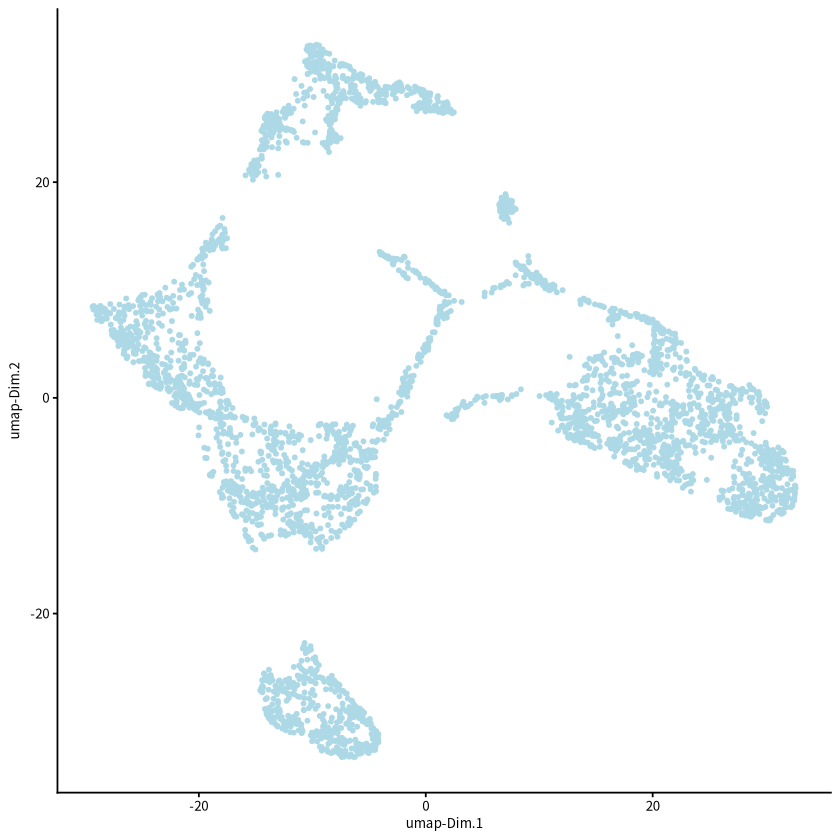

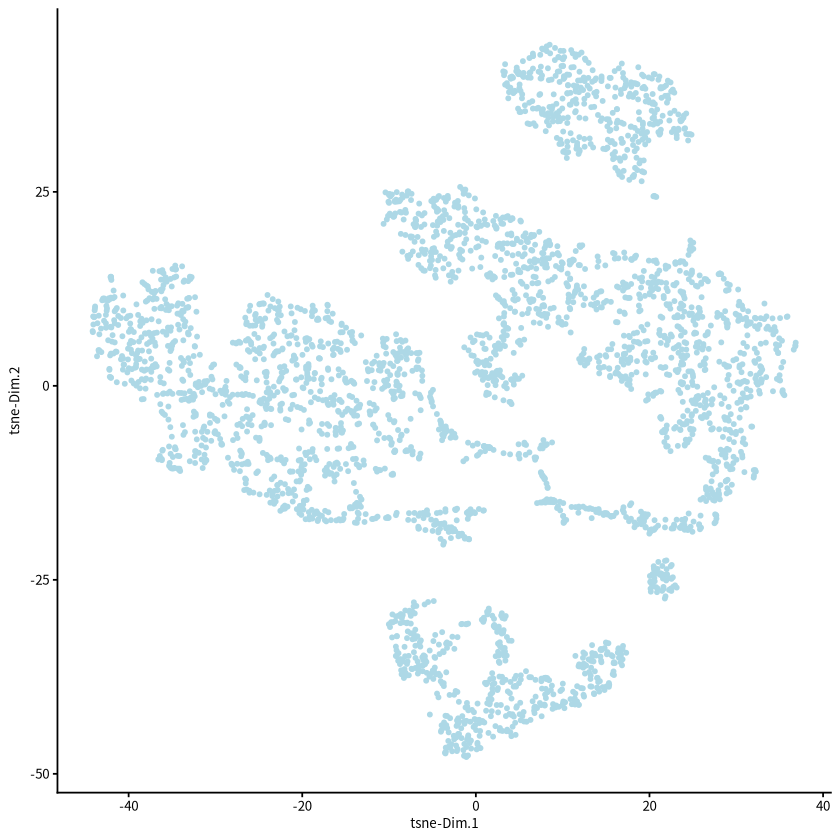

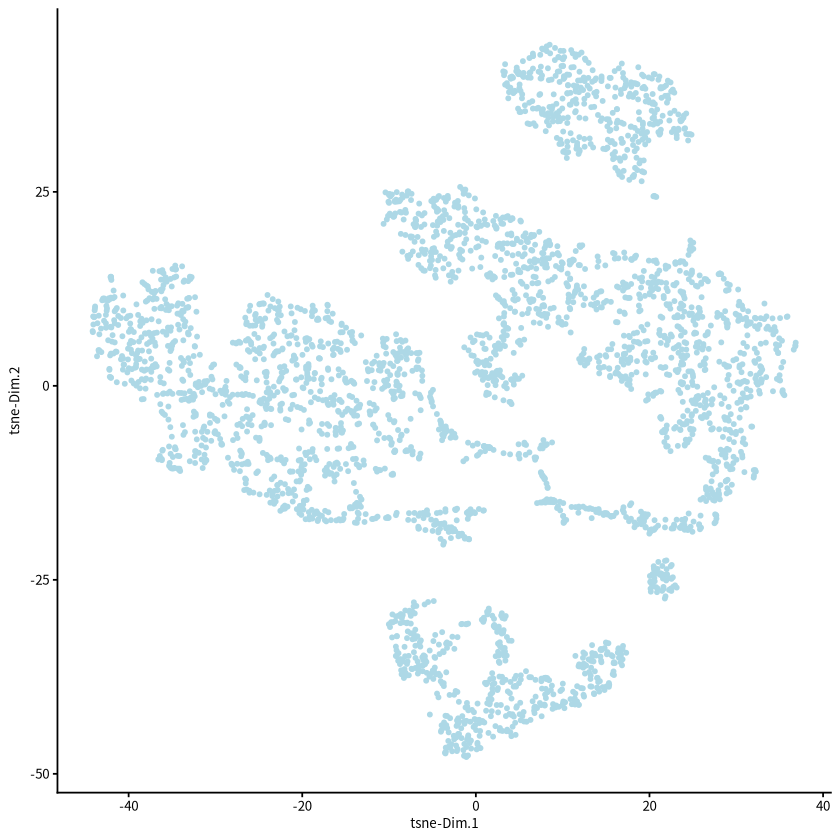

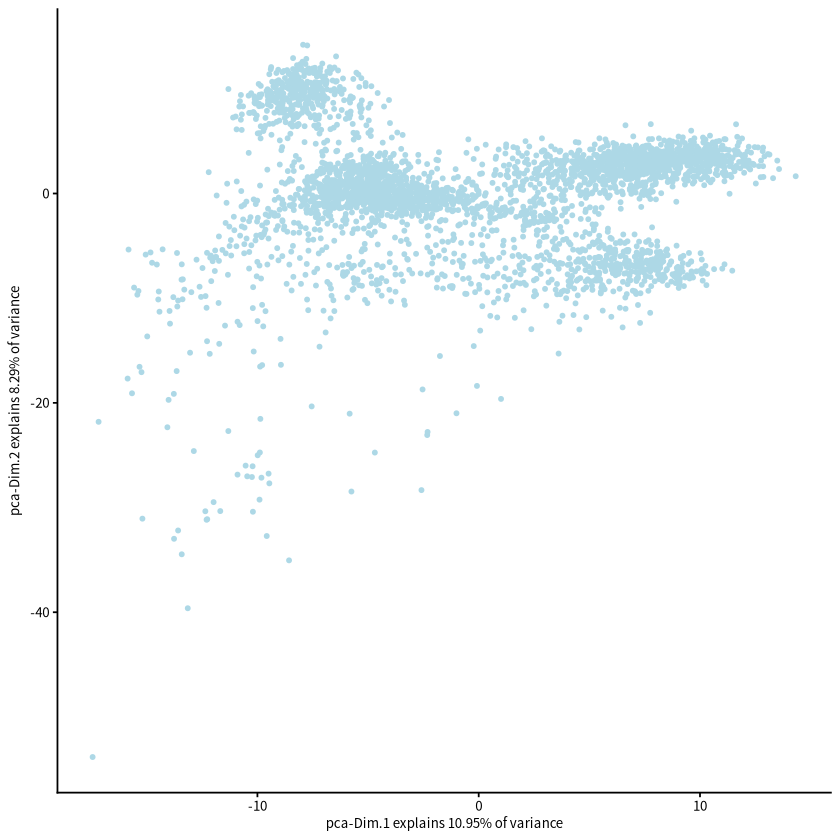

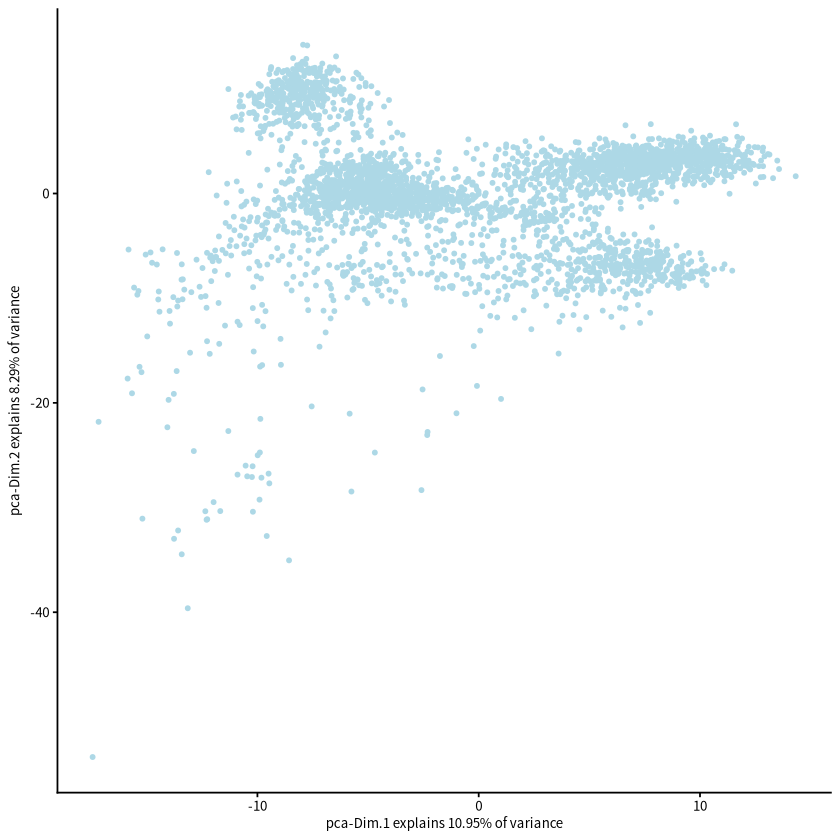

In [21]:
# UMAP
my_giotto_object <- runUMAP(my_giotto_object, dimensions_to_use = 1:5)
plotUMAP(gobject = my_giotto_object)

# TSNE
my_giotto_object <- runtSNE(my_giotto_object, dimensions_to_use = 1:5)
plotTSNE(gobject = my_giotto_object)

# plot PCA results
plotPCA(my_giotto_object)

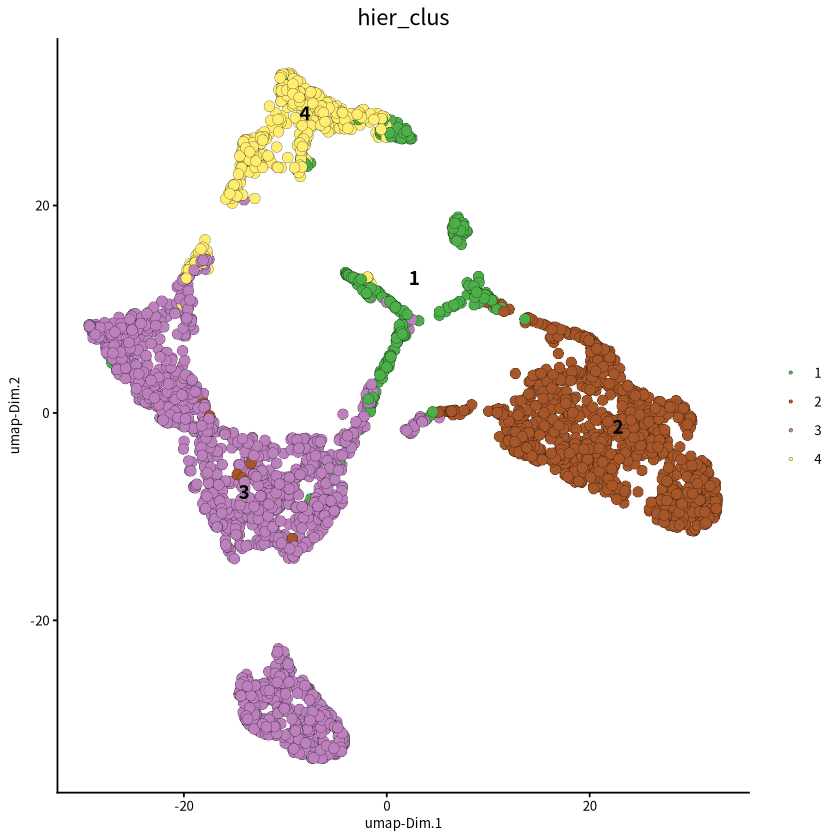

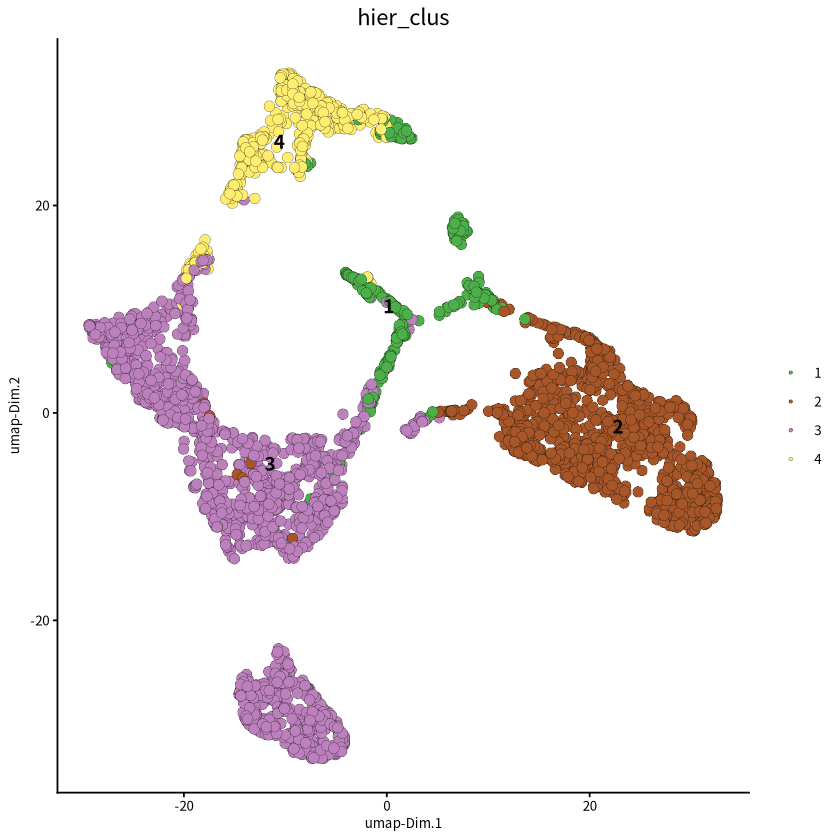

In [22]:
my_giotto_object = doHclust(my_giotto_object, k = 4, name = 'hier_clus')
plotUMAP_2D(my_giotto_object, cell_color = 'hier_clus', point_size = 3)

In [ ]:
my_giotto_object@cell_metadata$hier_clus=

 int [1:3476] 1 2 3 2 2 2 2 2 4 2 ...


In [25]:
single_cell_DT = fread('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/deconvolution/Cytospace/sc_expression.tsv')
single_cell_matrix = Giotto:::dt_to_matrix(single_cell_DT)
single_cell_matrix[1:4, 1:4]



4 x 4 sparse Matrix of class "dgCMatrix"
        ADsum_NCF60_TGGCCTGCACGAACAG-1 ADsum_NCF71_TTCGCAACACCTATAG-1
Xkr4                                 .                              .
Gm1992                               .                              .
Gm37381                              .                              .
Rp1                                  .                              .
        ADsum_NCF64_CGTGCACAGCCTCTGT-1 ADsum_NCF71_AGTGCCGGTTATGTGG-1
Xkr4                                 .                              .
Gm1992                               .                              .
Gm37381                              .                              .
Rp1                                  .                              .

In [28]:
# Single cell annotation vector
cell_annotations = read.table(file = '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/deconvolution/Cytospace/cell_type_labels.tsv',header = T)


In [30]:
cell_annotations = as.vector(cell_annotations$cell_type)
cell_annotations[1:10]

# 1.2 create rank matrix
rank_matrix = makeSignMatrixRank(sc_matrix = single_cell_matrix, sc_cluster_ids = cell_annotations)


# 1.3 enrichment test with RANK
# runSpatialEnrich() can also be used as a wrapper for all currently provided enrichment options
my_giotto_object = runRankEnrich(gobject = my_giotto_object, sign_matrix = rank_matrix)



[1] "Microglia" "Microglia" "Microglia" "Microglia" "Microglia" "Microglia"
 [7] "Microglia" "Microglia" "Microglia" "Microglia"

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.6 GiB”


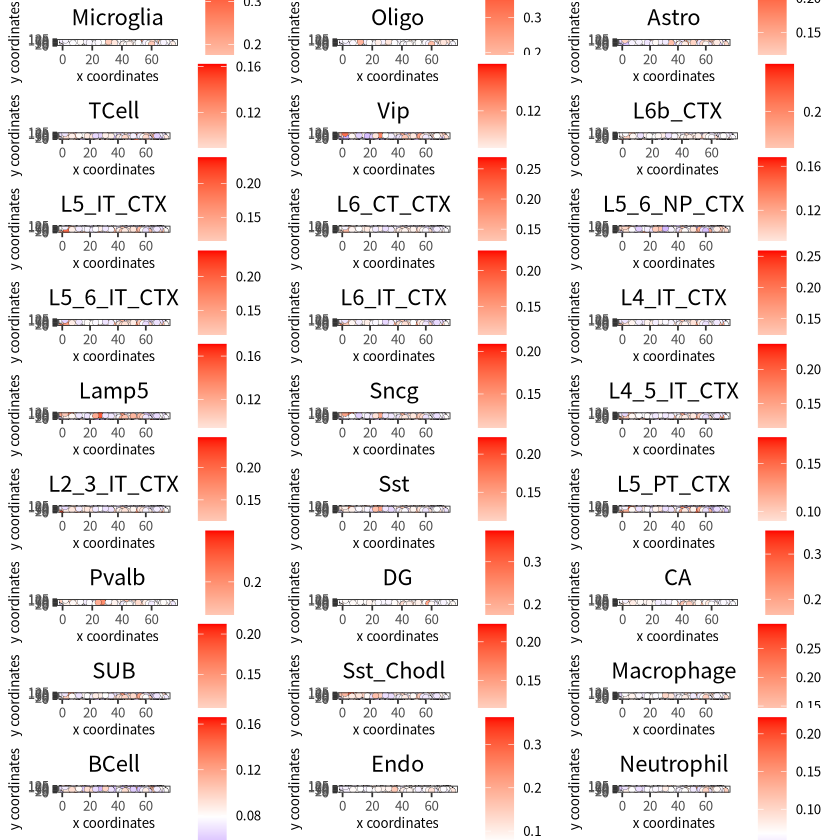

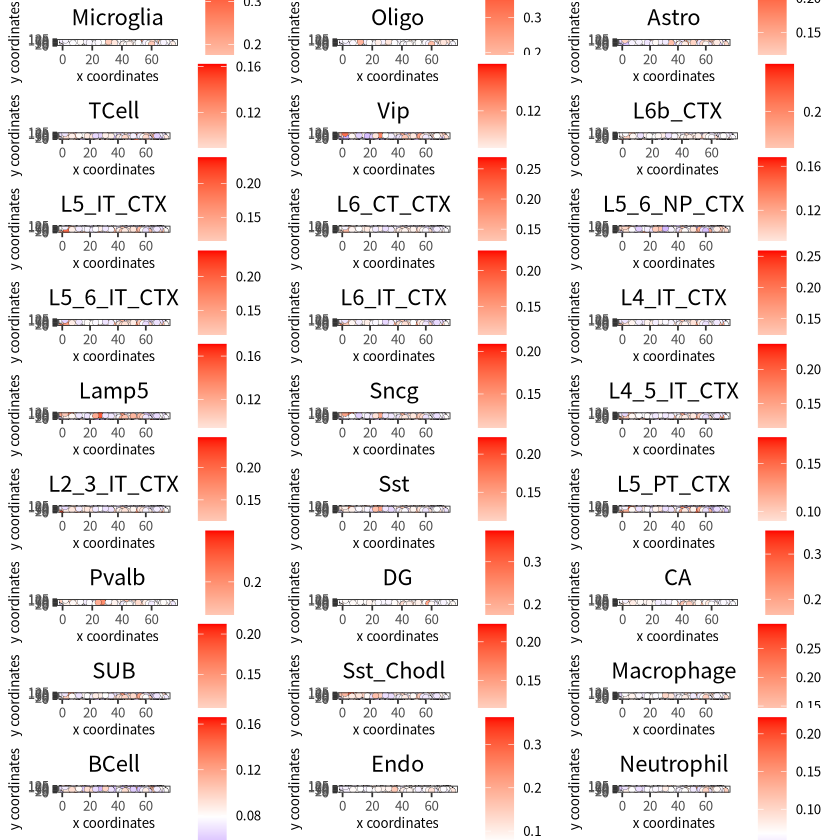

In [35]:
cell_types_subset = unique(cell_annotations)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'rank',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 3,coord_fix_ratio = NULL, point_size = 1.75)

In [38]:
markersall=read.table('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/makers.txt',sep='\t',header=T)

In [54]:
# 筛选条件
selected <- markersall[markersall$p_val_adj < 0.00001 & markersall$avg_log2FC > 4, ]

# 按 cluster 分组，提取基因名称
marker_genes_per_cluster <- split(selected$gene, selected$cluster)

In [59]:
# 假设 marker_genes_per_cluster 是之前生成的命名列表
# 只保留基因长度大于 0 的 cluster
sign_list <- marker_genes_per_cluster[lengths(marker_genes_per_cluster) > 0]
sign_names <- names(sign_list)

# 生成签名矩阵（需加载 Giotto 或相关包）
signature_matrix <- makeSignMatrixPAGE(
    sign_names = sign_names,
    sign_list = sign_list
)

# 查看结果
dim(signature_matrix)
colnames(signature_matrix)  # 显示签名名称

[1] 3093   27

[1] "Astro"       "BCell"       "CA"          "DG"          "Endo"       
 [6] "L2_3_IT_CTX" "L4_5_IT_CTX" "L4_IT_CTX"   "L5_6_IT_CTX" "L5_6_NP_CTX"
[11] "L5_IT_CTX"   "L5_PT_CTX"   "L6_CT_CTX"   "L6_IT_CTX"   "L6b_CTX"    
[16] "Lamp5"       "Macrophage"  "Microglia"   "Neutrophil"  "Oligo"      
[21] "Pvalb"       "SUB"         "Sncg"        "Sst"         "Sst_Chodl"  
[26] "TCell"       "Vip"

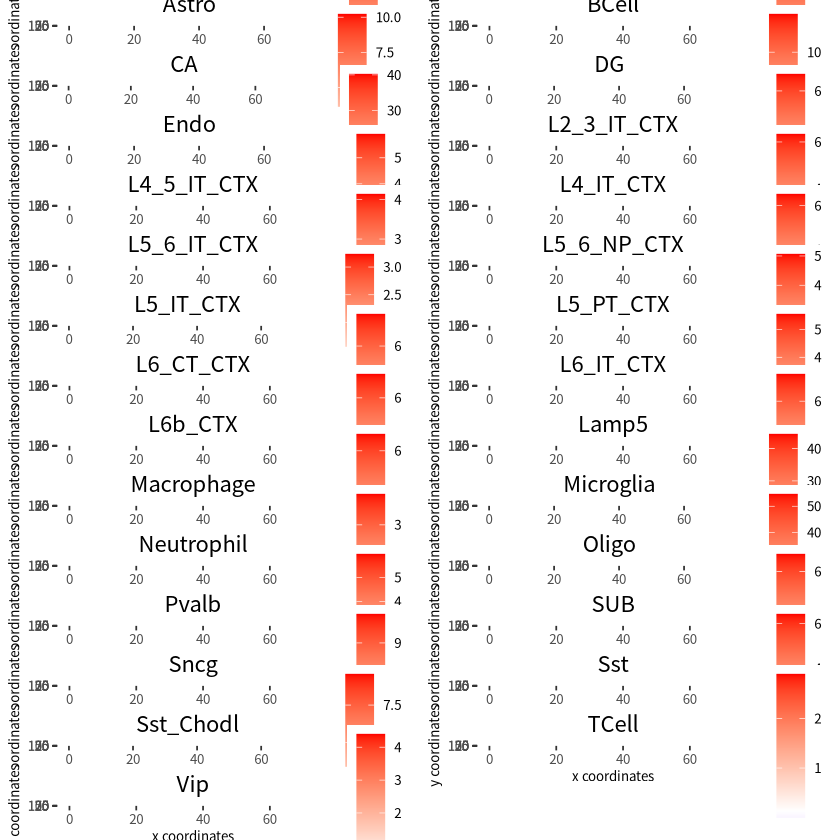

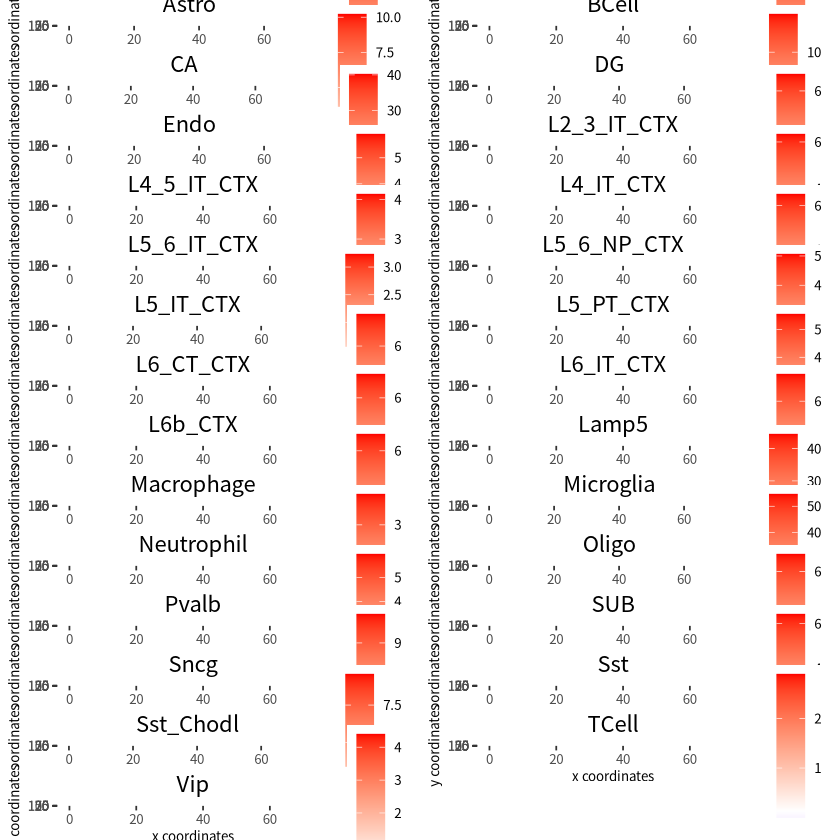

In [60]:
my_giotto_object = runHyperGeometricEnrich(gobject = my_giotto_object,
                   sign_matrix = signature_matrix)

cell_types_subset = colnames(signature_matrix)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'hypergeometric',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 2,coord_fix_ratio = NULL, point_size = 2.75)

In [ ]:
saveRDS(my_giotto_object, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object.rds")
saveRDS(signature_matrix, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/signature_matrix.rds")

In [2]:
my_giotto_object=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object.rds")
signature_matrix=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/signature_matrix.rds")

In [7]:
my_giotto_object@cell_metadata$cluster=my_giotto_object@cell_metadata$hier_clus

In [9]:
colnames(my_giotto_object@cell_metadata)

[1] "cell_ID"   "hier_clus" "cluster"

In [10]:
my_giotto_object = runDWLSDeconv(gobject = my_giotto_object, sign_matrix = signature_matrix, cluster_column = "hier_clus")

[1] "The 2090 overlapped genes between signature matrix and\nspatial expression profile"


In [ ]:
signature_matrix

In [13]:
saveRDS(my_giotto_object, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object.rds")


In [2]:
my_giotto_object=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object.rds")


In [8]:
write.table(my_giotto_object@cell_metadata, file='Spot_cluster.txt',sep='\t',quote = F)

In [11]:
write.table(my_giotto_object@spatial_enrichment$DWLS,file = 'spatialDWLS_dec.csv',sep=',',quote = F,row.names = F)